### Load Wisconsin Breast Cancer Data Set from Scientific Kit Learn

In [11]:
from sklearn.datasets import load_breast_cancer

breast_cancer = load_breast_cancer(as_frame=True)
df = breast_cancer.frame
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


### Identify outliers using two methods for only two features of my choice and visualize

##### I will pick mean compactness and mean concavity

#### Z-Score method

In [12]:
df = df.rename(columns={
    'mean compactness': 'mean_compactness',
    'mean concavity': 'mean_concavity'
})

### Visualize

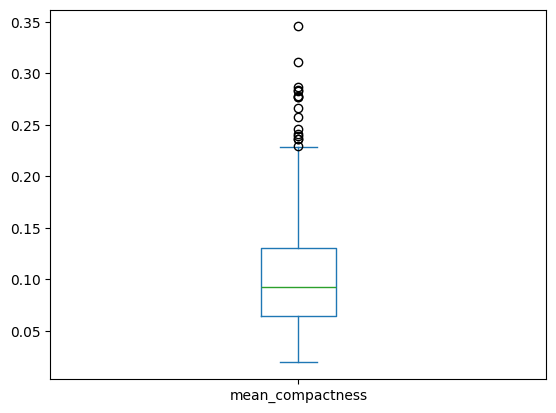

In [13]:
import matplotlib.pyplot as plt

df['mean_compactness'].plot(kind='box')
plt.show()

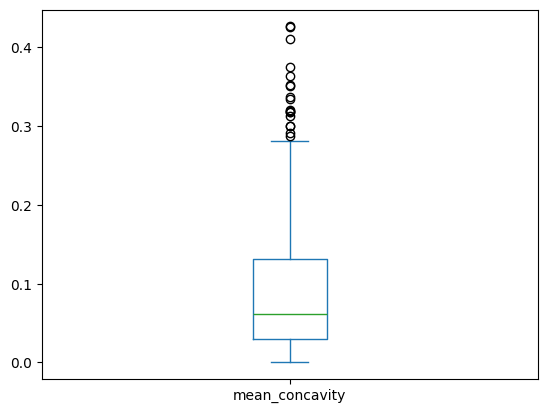

In [5]:
import matplotlib.pyplot as plt

df['mean_concavity'].plot(kind='box')
plt.show()

In [14]:
def z_score_outliers(dataframe, column):
    dataframe['z_score'] = (dataframe[column] - dataframe[column].mean()) / dataframe[column].std()
    threshold = 3
    is_outlier = dataframe['z_score'].apply(lambda x: abs(x) > threshold)
    outliers = dataframe[is_outlier] # this one return entire dataframe where is outlier is true
    return outliers

# Call only the column mean compactness after getting the outliers
display(z_score_outliers(df,'mean_compactness')[
    ['mean_compactness']
])

display(z_score_outliers(df,'mean_concavity')[
    ['mean_concavity']
])


,mean_compactness
0,0.2776
3,0.2839
78,0.3454
82,0.2665
108,0.2768
122,0.2867
181,0.2832
258,0.3114
567,0.2770


,mean_concavity
78,0.3754
82,0.3339
108,0.4264
122,0.4268
152,0.4108
202,0.3523
352,0.3368
461,0.3635
567,0.3514


## IQR 

In [ ]:
def iqr_outliers(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    is_outlier = dataframe[column].apply(lambda x: x > upper_bound or x < lower_bound)
    outliers = dataframe[is_outlier]                # Boolean indexing/masking
    return outliers, is_outlier

display(iqr_outliers(df,'mean_compactness')[0][     # Get outliers but bring column mean_compactness
    ['mean_compactness']
])

display(iqr_outliers(df,'mean_concavity')[0][       # Get outliers but bring column mean_concavity
    ['mean_concavity']
])

,mean_compactness
0,0.2776
3,0.2839
9,0.2396
12,0.2458
14,0.2293
78,0.3454
82,0.2665
108,0.2768
122,0.2867
181,0.2832


,mean_concavity
0,0.3001
68,0.3130
78,0.3754
82,0.3339
108,0.4264
112,0.3003
122,0.4268
152,0.4108
180,0.2871
202,0.3523


### Handling outliers: remove and replace with median from dataset

In [11]:
import numpy as np

median_mean_compactness = df['mean_compactness'].median()

#Returns only is_outlier from IQR that can be use later to replace median
_, is_outlier = iqr_outliers(df, 'mean_compactness')

df['mean_compactness'] = np.where(is_outlier, median_mean_compactness, df['mean_compactness'])

median_mean_concavity = df['mean_concavity'].median()

#Returns only is_outlier from IQR that can be use later to replace median
_, is_outlier = iqr_outliers(df, 'mean_concavity')

df['mean_concavity'] = np.where(is_outlier, median_mean_concavity, df['mean_concavity'])

print(df)

     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0          17.99         10.38          122.80     1001.0          0.11840   
1          20.57         17.77          132.90     1326.0          0.08474   
2          19.69         21.25          130.00     1203.0          0.10960   
3          11.42         20.38           77.58      386.1          0.14250   
4          20.29         14.34          135.10     1297.0          0.10030   
..           ...           ...             ...        ...              ...   
564        21.56         22.39          142.00     1479.0          0.11100   
565        20.13         28.25          131.20     1261.0          0.09780   
566        16.60         28.08          108.30      858.1          0.08455   
567        20.60         29.33          140.10     1265.0          0.11780   
568         7.76         24.54           47.92      181.0          0.05263   

     mean_compactness  mean_concavity  mean concave points  mea

### Feature Scaling: Apply Min-Max Scaling and Standardization

In [12]:
from sklearn import preprocessing
import pandas as pd

features_to_scale = ['mean_compactness', 'mean_concavity']

minmax_scaler = preprocessing.MinMaxScaler(feature_range=(0,1))
minmax_scaled = minmax_scaler.fit_transform(df[features_to_scale])

minmax_df = pd.DataFrame(
    minmax_scaled,
    columns=[f"{column}_MinMax" for column in features_to_scale],
    index = df.index
)

minmax_df.head().round(3)

,mean_compactness_MinMax,mean_concavity_MinMax
0,0.350,0.219
1,0.284,0.309
2,0.672,0.702
3,0.350,0.859
4,0.543,0.705


In [13]:
from sklearn import preprocessing
import pandas as pd

features_to_scale = ['mean_compactness', 'mean_concavity']

standard_scaler = preprocessing.StandardScaler()
standard_scaled = standard_scaler.fit_transform(df[features_to_scale])

standard_df = pd.DataFrame(
    standard_scaled,
    columns=[f"{column}_Standard" for column in features_to_scale],
    index = df.index
)

standard_df.head().round(3)

,mean_compactness_Standard,mean_concavity_Standard
0,-0.152,-0.284
1,-0.466,0.107
2,1.359,1.809
3,-0.152,2.487
4,0.750,1.818


#### Write a brief reflection discussing the importance of feature scaling and handling outliers in machine learning. Discuss how outliers might affect model performance and the advantages of using feature scaling

Machine learning requires data governance, data quality, and observability. Feature scaling helps in different ways: Min-Max scaling transforms values to a range between 0 and 1 and works well when there are no strong outliers. Standard scaling works best when the data is approximately normally distributed, while Robust Scaling is better when the dataset contains many outliers. Each method provides different benefits depending on the data.

Handling outliers is also important because it helps reveal real patterns and ensures that each data point contributes appropriately to prediction. Outliers can increase error and reduce prediction accuracy. For example, in Linear Regression fitted with Ordinary Least Squares (OLS), large outliers can increase the difference between predicted and true values, causing the model to overemphasize those extreme points.

Outliers can also increase bias during training and make optimization harder. In neural networks, they can affect gradient updates and lead to unstable learning, especially with a high learning rate. In linear or logistic regression, outliers can shift coefficients in the wrong direction, which may increase false positives and false negatives. In tree-based models such as Random Forest and XGBoost, outliers can influence splits and lead to poorer generalization.